In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("All libraries imported successfully!")

All libraries imported successfully!


In [181]:
metadata=pd.read_csv('/Users/avdhipagaria/Desktop/battery_health_project/cleaned_dataset/metadata.csv')
metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


In [182]:
print(f"Total Rows: {metadata.shape[0]}")
print(f"Total Columns: {metadata.shape[1]}")

Total Rows: 7565
Total Columns: 10


In [183]:
metadata.columns.tolist()

['type',
 'start_time',
 'ambient_temperature',
 'battery_id',
 'test_id',
 'uid',
 'filename',
 'Capacity',
 'Re',
 'Rct']

In [184]:
print('Test types',metadata['type'].value_counts())

Test types type
charge       2815
discharge    2794
impedance    1956
Name: count, dtype: int64


In [185]:
print("\n=== TEST TYPES (percentage) ===")
print(metadata['type'].value_counts(normalize=True).round(2))


=== TEST TYPES (percentage) ===
type
charge       0.37
discharge    0.37
impedance    0.26
Name: proportion, dtype: float64


In [186]:
print(metadata['battery_id'].unique())


<StringArray>
['B0047', 'B0045', 'B0048', 'B0046', 'B0043', 'B0032', 'B0039', 'B0040',
 'B0029', 'B0028', 'B0042', 'B0034', 'B0038', 'B0033', 'B0030', 'B0041',
 'B0027', 'B0044', 'B0036', 'B0025', 'B0026', 'B0031', 'B0049', 'B0050',
 'B0052', 'B0051', 'B0006', 'B0005', 'B0007', 'B0018', 'B0053', 'B0054',
 'B0056', 'B0055']
Length: 34, dtype: str


In [187]:
print(metadata.isnull().sum())


type                      0
start_time                0
ambient_temperature       0
battery_id                0
test_id                   0
uid                       0
filename                  0
Capacity               4771
Re                     5609
Rct                    5609
dtype: int64


EXAMINING THE DATASET

In [188]:
battery_df = pd.read_csv('/Users/avdhipagaria/Desktop/battery_health_project/cleaned_dataset/data/00001.csv')
battery_df.columns.tolist()

['Voltage_measured',
 'Current_measured',
 'Temperature_measured',
 'Current_load',
 'Voltage_load',
 'Time']

In [189]:
battery_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625


In [190]:
battery_df.shape

(490, 6)

In [191]:
print(f"Total Rows: {battery_df.shape[0]}")
print(f"Total Columns: {battery_df.shape[1]}")

Total Rows: 490
Total Columns: 6


In [192]:
print(battery_df.describe())

       Voltage_measured  Current_measured  Temperature_measured  Current_load  \
count        490.000000        490.000000            490.000000    490.000000   
mean           3.475266         -0.952767              8.272423      0.957153   
std            0.284626          0.201448              1.455269      0.202690   
min            2.470612         -1.001101              5.008084      0.000200   
25%            3.336993         -0.995898              7.313213      1.000000   
50%            3.491946         -0.995207              8.184590      1.000000   
75%            3.655987         -0.994648              9.025544      1.000000   
max            4.246764          0.000252             12.376816      1.000000   

       Voltage_load         Time  
count    490.000000   490.000000  
mean       2.817939  3205.134141  
std        0.644985  1861.395346  
min        0.000000     0.000000  
25%        2.790500  1598.417750  
50%        2.945500  3200.492500  
75%        3.105750  4809

In [193]:
print(battery_df.isnull().sum())

Voltage_measured        0
Current_measured        0
Temperature_measured    0
Current_load            0
Voltage_load            0
Time                    0
dtype: int64


In [194]:
import os

data_folder = 'cleaned_dataset/data/'

all_batteries = []

for filename in sorted(os.listdir(data_folder)):
    
    if filename.endswith('.csv'):

        filepath = os.path.join(data_folder, filename)
        df = pd.read_csv(filepath)

        df['battery_id'] = filename.replace('.csv', '')

        all_batteries.append(df)

full_df = pd.concat(all_batteries, ignore_index=True)

print(f"✅ Total Rows: {full_df.shape[0]}")
print(f"✅ Total Columns: {full_df.shape[1]}")
print(f"✅ Total Batteries: {full_df['battery_id'].nunique()}")
print(f"\nFirst 5 rows:")
print(full_df.head())

✅ Total Rows: 7376834
✅ Total Columns: 14
✅ Total Batteries: 7565

First 5 rows:
   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.246711          0.000252              6.212696        0.0002   
1          4.246764         -0.001411              6.234019        0.0002   
2          4.039277         -0.995093              6.250255        1.0000   
3          4.019506         -0.996731              6.302176        1.0000   
4          4.004763         -0.992845              6.361645        1.0000   

   Voltage_load    Time battery_id Sense_current Battery_current  \
0         0.000   0.000      00001           NaN             NaN   
1         4.262   9.360      00001           NaN             NaN   
2         3.465  23.281      00001           NaN             NaN   
3         3.451  36.406      00001           NaN             NaN   
4         3.438  49.625      00001           NaN             NaN   

  Current_ratio Battery_impedance Rectified_Imp

So what we have concluded from here is that the csv file sin cleaned_dataset/data folder contains the infomation per cycle(charging,discharging,and impedenece)
thats why we have so 7565 files.
Additionally if we talk about columns in general there are only 6 columns which are common in all the csv files, but 8 extra columns are present in few files and may not be present in other, thats why if that particular column will not be present in any of the file its value will be NaN.


In [195]:
print(metadata.columns.tolist())

['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']


In [196]:
metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


So we are basically removing the .csv extension in code below in order to join metadata and full_df because we want a common file to work on and we need a common common to perform the join.

In [197]:
metadata = pd.read_csv('cleaned_dataset/metadata.csv')
metadata['file_name']=metadata['filename'].str.replace('.csv','')
print(metadata.columns.tolist())  
print(metadata.head()) 

['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'file_name']
        type                                         start_time  \
0  discharge  [2010.       7.      21.      15.       0.    ...   
1  impedance  [2010.       7.      21.      16.      53.    ...   
2     charge  [2010.       7.      21.      17.      25.    ...   
3  impedance                    [2010    7   21   20   31    5]   
4  discharge  [2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...   

   ambient_temperature battery_id  test_id  uid   filename  \
0                    4      B0047        0    1  00001.csv   
1                   24      B0047        1    2  00002.csv   
2                    4      B0047        2    3  00003.csv   
3                   24      B0047        3    4  00004.csv   
4                    4      B0047        4    5  00005.csv   

             Capacity                   Re                  Rct file_name  
0  1.674304744697520

So basically the full_df is nothing but just the concatenation of tall the csv file

In [198]:
full_df.head()

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time,battery_id,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance,Current_charge,Voltage_charge
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000,00001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360,00001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281,00001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406,00001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625,00001,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [199]:
full_df.shape

(7376834, 14)

## The next step that we will be performing is of joinig the two tables(full_df and metadata.csv) on a common column:
full_df -> batter_id
metadata -> file_name
both the columns has same value

In [200]:
merged_df = full_df.merge(
    metadata[['file_name', 'battery_id', 'type', 'Capacity', 'Re', 'Rct']],
    left_on='battery_id',      # column in full_df
    right_on='file_name',      # column in metadata
    how='left'                 # keep all rows from full_df
)
print(merged_df.columns.tolist())
print(merged_df.head())
print(merged_df.shape)


['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'battery_id_x', 'Sense_current', 'Battery_current', 'Current_ratio', 'Battery_impedance', 'Rectified_Impedance', 'Current_charge', 'Voltage_charge', 'file_name', 'battery_id_y', 'type', 'Capacity', 'Re', 'Rct']
   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.246711          0.000252              6.212696        0.0002   
1          4.246764         -0.001411              6.234019        0.0002   
2          4.039277         -0.995093              6.250255        1.0000   
3          4.019506         -0.996731              6.302176        1.0000   
4          4.004763         -0.992845              6.361645        1.0000   

   Voltage_load    Time battery_id_x Sense_current Battery_current  \
0         0.000   0.000        00001           NaN             NaN   
1         4.262   9.360        00001           NaN             NaN   
2         3

## While executing this code I got a problem i was getting the values for voltage_charge,rectified_impedence and many other columns to be NaN, i checked where i am encountering the problem by unning through test.

In [201]:
print(f"Data type: {full_df['battery_id'].dtype}")
print(f"Sample values: {full_df['battery_id'].unique()[:5]}")


Data type: str
Sample values: <StringArray>
['00001', '00002', '00003', '00004', '00005']
Length: 5, dtype: str


In [202]:
print(f"Data type: {metadata['file_name'].dtype}")
print(f"Sample values: {metadata['file_name'].unique()[:5]}")

Data type: str
Sample values: <StringArray>
['00001', '00002', '00003', '00004', '00005']
Length: 5, dtype: str


In [203]:
test_value = full_df['battery_id'].iloc[0]
print(f"Value from full_df: '{test_value}'")
print(f"Length: {len(test_value)}")

test_value2 = metadata['file_name'].iloc[0]
print(f"\nValue from metadata: '{test_value2}'")
print(f"Length: {len(test_value2)}")

# Try to find a match manually
match = metadata[metadata['file_name'] == test_value]
print(f"Rows found: {len(match)}")
print(match)

Value from full_df: '00001'
Length: 5

Value from metadata: '00001'
Length: 5
Rows found: 1
        type                                         start_time  \
0  discharge  [2010.       7.      21.      15.       0.    ...   

   ambient_temperature battery_id  test_id  uid   filename  \
0                    4      B0047        0    1  00001.csv   

             Capacity   Re  Rct file_name  
0  1.6743047446975208  NaN  NaN     00001  


In [204]:
# Clean correct merge
merged_df = full_df.merge(
    metadata[['file_name', 'battery_id', 'type', 'Capacity']],
    left_on='battery_id',      
    right_on='file_name',      
    how='left'
)

# Rename columns to make it clean
merged_df = merged_df.rename(columns={
    'battery_id_x': 'file_id',       
    'battery_id_y': 'battery_id',    
})

# Check result
print("=== MERGED SUCCESSFULLY ===")
print(f"Total Rows: {merged_df.shape[0]}")
print(f"\nFirst 5 rows:")
print(merged_df[['file_id', 'battery_id', 'type', 
                  'Capacity', 'Voltage_measured', 
                  'Temperature_measured']].head())

=== MERGED SUCCESSFULLY ===
Total Rows: 7376834

First 5 rows:
  file_id battery_id       type            Capacity  Voltage_measured  \
0   00001      B0047  discharge  1.6743047446975208          4.246711   
1   00001      B0047  discharge  1.6743047446975208          4.246764   
2   00001      B0047  discharge  1.6743047446975208          4.039277   
3   00001      B0047  discharge  1.6743047446975208          4.019506   
4   00001      B0047  discharge  1.6743047446975208          4.004763   

   Temperature_measured  
0              6.212696  
1              6.234019  
2              6.250255  
3              6.302176  
4              6.361645  


## Step 8 — Understanding Battery Cycles (B0047 Analysis)

### What We Did:
We investigated whether 00001 was truly the first cycle 
of battery B0047 before using its Capacity as the 
original/maximum capacity for SoH calculation.

### Why We Did It:
Before calculating SoH we need to know the ORIGINAL capacity
of the battery (when it was brand new). If we pick the wrong
starting point our SoH calculation will be incorrect.

### What We Found:
- Battery B0047 has 72 discharge cycles total
- File 00001 has the HIGHEST capacity (1.6743 Ah) 
- Capacity drops every single cycle (battery aging) 
- Final capacity = 1.1567 Ah = ~69% health → RECYCLE 

### Why File IDs Jump (00001 → 00005 → 00007):
Between every discharge test there are charge and 
impedance tests. So file IDs skip numbers because 
we filtered ONLY discharge rows.

### Key Takeaway:
- 00001 IS the first cycle 
- 1.6743 IS the original capacity 
- Safe to use for SoH calculation 

### Formula We Will Use:
SoH % = (Current Capacity / Original Capacity) × 100

Example:
- Original Capacity = 1.6743 (cycle 1)
- Current Capacity  = 1.1567 (cycle 72)
- SoH = (1.1567 / 1.6743) × 100 = 69.1% (RECYCLE!) 

In [205]:
b0047 = merged_df[merged_df['battery_id'] == 'B0047']

b0047_discharge = b0047[b0047['type'] == 'discharge']

b0047_discharge_sorted = b0047_discharge.sort_values('file_id')

b0047_capacity = b0047_discharge_sorted.groupby('file_id')['Capacity'].first().reset_index()

print(" B0047 DISCHARGE CYCLES IN ORDER ")
print(b0047_capacity)

 B0047 DISCHARGE CYCLES IN ORDER 
   file_id            Capacity
0    00001  1.6743047446975208
1    00005  1.5243662105099023
2    00007  1.5080762969973425
3    00009  1.4835577960067696
4    00011  1.4671391666146525
..     ...                 ...
67   00173  1.2031062978889062
68   00175  1.1897147112197684
69   00177   1.177422568842014
70   00179   1.158443027293818
71   00181  1.1567087516841796

[72 rows x 2 columns]


So in above code we were just filtering fot one battery just to undertand the thought process, but now instead of just one battery we are filtering all the battery at once and we are storing it in a copy so our original data stays untouched.

In [206]:
discharge_df = merged_df[merged_df['type'] == 'discharge'].copy()

discharge_df = discharge_df.sort_values(['battery_id', 'file_id'])

cycle_df = discharge_df.groupby(['battery_id', 'file_id'])['Capacity'].first().reset_index()

print("=== ONE ROW PER CYCLE ===")
print(f"Total cycles: {cycle_df.shape[0]}")
print(f"\nFirst 10 rows:")
print(cycle_df.head(10))
print(cycle_df['battery_id'].nunique())

=== ONE ROW PER CYCLE ===
Total cycles: 2794

First 10 rows:
  battery_id file_id            Capacity
0      B0005   05122  1.8564874208181574
1      B0005   05124   1.846327249719927
2      B0005   05126  1.8353491942234077
3      B0005   05128  1.8352625275821128
4      B0005   05130  1.8346455082120419
5      B0005   05132  1.8356616600675495
6      B0005   05134  1.8351461429226603
7      B0005   05136  1.8257567905665537
8      B0005   05138  1.8247738529891333
9      B0005   05140   1.824613268496936
34


In [207]:
print(cycle_df['file_id'].nunique())


2794


So in data folder we have in total 7565 files  for charging,discharging and impedence:

Discharge (2,794 files)
- battery being emptied
- Capacity measured here
- used for SoH and RUL 

Charge (~2,400 files)
- battery being filled
- no Capacity measurement
- used for charging pattern analysis

Impedance (~2,400 files)
- health checkup test
- measures internal resistance
- used for Anomaly Detection later!

# SOH and RUL CALCULATION

In [208]:
cycle_df['Capacity'] = pd.to_numeric(cycle_df['Capacity'], errors='coerce')

apply() consumed battery_id and made it an index causing the error, while transform() kept battery_id as a proper column so everything worked!

In [209]:
cycle_df['Capacity'] = pd.to_numeric(cycle_df['Capacity'], errors='coerce')

cycle_df['cycle_number'] = cycle_df.groupby('battery_id').cumcount() + 1

# Calculate SoH per battery
cycle_df['max_capacity'] = cycle_df.groupby('battery_id')['Capacity'].transform('max')
cycle_df['SoH'] = (cycle_df['Capacity'] / cycle_df['max_capacity']) * 100

In [210]:
# Calculate RUL per battery
cycle_df['total_cycles'] = cycle_df.groupby(
    'battery_id')['cycle_number'].transform('max')
cycle_df['RUL'] = cycle_df['total_cycles'] - cycle_df['cycle_number']

cycle_df = cycle_df.drop(columns=['max_capacity', 'total_cycles'])

In [211]:
print("SoH AND RUL CALCULATED")
print(f"Total rows: {cycle_df.shape[0]}")
print(f"\nFirst 10 rows:")
print(cycle_df[['battery_id', 'file_id', 
                'cycle_number', 'Capacity', 
                'SoH', 'RUL']].head(10))

SoH AND RUL CALCULATED
Total rows: 2794

First 10 rows:
  battery_id file_id  cycle_number  Capacity         SoH  RUL
0      B0005   05122             1  1.856487  100.000000  167
1      B0005   05124             2  1.846327   99.452721  166
2      B0005   05126             3  1.835349   98.861386  165
3      B0005   05128             4  1.835263   98.856718  164
4      B0005   05130             5  1.834646   98.823482  163
5      B0005   05132             6  1.835662   98.878217  162
6      B0005   05134             7  1.835146   98.850449  161
7      B0005   05136             8  1.825757   98.344690  160
8      B0005   05138             9  1.824774   98.291743  159
9      B0005   05140            10  1.824613   98.283094  158


# VISUALIZATION

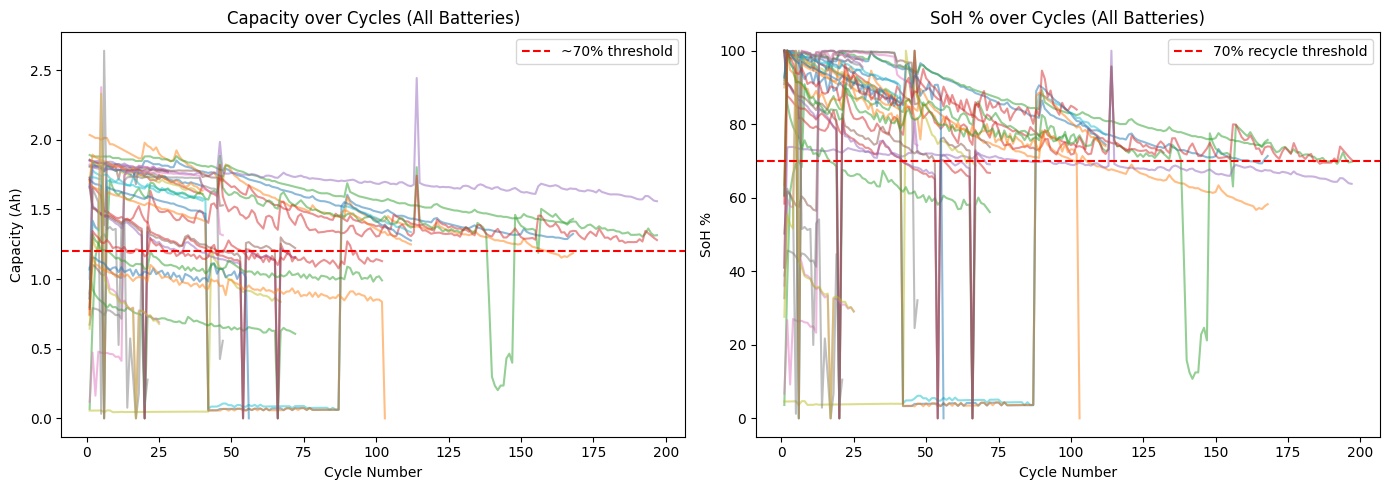

Graph saved as battery_aging.png!


In [212]:
import matplotlib.pyplot as plt

# Creates a 1x2 grid of subplots, 1 for capacity and 1 for SoH
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In this we are looping through each battery
for battery in cycle_df['battery_id'].unique():
    
    # Filter one battery at a time
    battery_data = cycle_df[cycle_df['battery_id'] == battery]
    # Graph 1 — Capacity 
    axes[0].plot(battery_data['cycle_number'], battery_data['Capacity'], alpha=0.5)

    # Graph 2 — SoH 
    axes[1].plot(battery_data['cycle_number'], battery_data['SoH'], alpha=0.5)

axes[0].axhline(y=1.2, color='red', linestyle='--', label='~70% threshold')

axes[1].axhline(y=70, color='red', linestyle='--', label='70% recycle threshold')

# Add titles and labels
axes[0].set_title('Capacity over Cycles (All Batteries)')
axes[0].set_xlabel('Cycle Number')
axes[0].set_ylabel('Capacity (Ah)')
axes[0].legend()

axes[1].set_title('SoH % over Cycles (All Batteries)')
axes[1].set_xlabel('Cycle Number')
axes[1].set_ylabel('SoH %')
axes[1].legend()

plt.tight_layout()
plt.savefig('battery_aging.png')
plt.show()

print("Graph saved as battery_aging.png!")


So what we can conclude from this graph is that the batteries above red line they are still useful and can be send to bESS for second life

Batteries below re dline they are weak and needs to be recycled or upcycled

One unusual behaviour in this graph is the sudden spike and drop, it is where something went wrong, and the engineers needs to be alerted

# Building ML Model 1 - SoH Prediction


In [213]:
sensor_df = discharge_df.groupby(['battery_id', 'file_id']).agg(
    avg_voltage     = ('Voltage_measured', 'mean'),
    avg_temperature = ('Temperature_measured', 'mean'),
    avg_current     = ('Current_measured', 'mean')).reset_index()

print("AVERAGE SENSOR READINGS PER CYCLE")
print(f"Total rows: {sensor_df.shape[0]}")
print(sensor_df.head())

AVERAGE SENSOR READINGS PER CYCLE
Total rows: 2794
  battery_id file_id  avg_voltage  avg_temperature  avg_current
0      B0005   05122     3.529829        32.572328    -1.818702
1      B0005   05124     3.537320        32.725235    -1.817560
2      B0005   05126     3.543737        32.642862    -1.816487
3      B0005   05128     3.543666        32.514876    -1.825589
4      B0005   05130     3.542343        32.382349    -1.826114


We grouped all 490 second-by-second readings of each cycle together and calculated the average voltage, temperature and current — reducing 7.3 million rows down to 2,794 rows - one summary row per cycle

In [214]:
merge_df=sensor_df.merge(cycle_df,on=['battery_id','file_id'],how='left')
print("Total number of rows:",merge_df.shape[0])
print("Total number of columns:",merge_df.shape[1])
print(merge_df.head())
print("Columns:",merge_df.columns.tolist())
print(merge_df.isnull().sum())

Total number of rows: 2794
Total number of columns: 9
  battery_id file_id  avg_voltage  avg_temperature  avg_current  Capacity  \
0      B0005   05122     3.529829        32.572328    -1.818702  1.856487   
1      B0005   05124     3.537320        32.725235    -1.817560  1.846327   
2      B0005   05126     3.543737        32.642862    -1.816487  1.835349   
3      B0005   05128     3.543666        32.514876    -1.825589  1.835263   
4      B0005   05130     3.542343        32.382349    -1.826114  1.834646   

   cycle_number         SoH  RUL  
0             1  100.000000  167  
1             2   99.452721  166  
2             3   98.861386  165  
3             4   98.856718  164  
4             5   98.823482  163  
Columns: ['battery_id', 'file_id', 'avg_voltage', 'avg_temperature', 'avg_current', 'Capacity', 'cycle_number', 'SoH', 'RUL']
battery_id          0
file_id             0
avg_voltage         0
avg_temperature     0
avg_current         0
Capacity           25
cycle_number   

Example 1 (earlier):
merged_df = full_df.merge(
    metadata,
    left_on='battery_id',
    right_on='file_name',
    how='left'
)

This is also the correct method to merge two dataframes, but we usually use this when we have two different names of the column in the two df

Example 2 (now):
model_df = sensor_df.merge(
    cycle_df,
    on=['battery_id', 'file_id'],
    how='left'
)

In this we have the same name for the column of two df that we need to merge.

In [215]:
nan_rows = merge_df[merge_df['SoH'].isna()]

print("=== NaN ROWS ===")
print(f"Total NaN rows: {len(nan_rows)}")
print(f"\nBatteries with NaN:")
print(nan_rows['battery_id'].unique())
print(f"\nSample NaN rows:")
print(nan_rows[['battery_id', 'file_id', 
                'avg_voltage', 'SoH']].head(10))


=== NaN ROWS ===
Total NaN rows: 25

Batteries with NaN:
<StringArray>
['B0050', 'B0052']
Length: 2, dtype: str

Sample NaN rows:
     battery_id file_id  avg_voltage  SoH
2377      B0050   04371     3.400187  NaN
2378      B0050   04373     0.296678  NaN
2379      B0050   04375     0.241978  NaN
2380      B0050   04377     0.234723  NaN
2410      B0052   04391     0.236898  NaN
2411      B0052   04395     0.338920  NaN
2412      B0052   04397     0.323481  NaN
2413      B0052   04399     0.323903  NaN
2414      B0052   04401     0.324473  NaN
2415      B0052   04403     0.324662  NaN


In [216]:
merge_df = merge_df.dropna(subset=['SoH'])
print(f"Rows after dropping NaN: {merge_df.shape[0]}")
print(f"\nNaN count after cleaning:")
print(merge_df.isnull().sum())

Rows after dropping NaN: 2769

NaN count after cleaning:
battery_id         0
file_id            0
avg_voltage        0
avg_temperature    0
avg_current        0
Capacity           0
cycle_number       0
SoH                0
RUL                0
dtype: int64


In [217]:
merge_df = merge_df.drop(columns=['Capacity'])
print("FINAL CLEAN DATAFRAME")
print(f"Total rows: {merge_df.shape[0]}")
print(f"Columns: {merge_df.columns.tolist()}")

FINAL CLEAN DATAFRAME
Total rows: 2769
Columns: ['battery_id', 'file_id', 'avg_voltage', 'avg_temperature', 'avg_current', 'cycle_number', 'SoH', 'RUL']


In [218]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

features = ['cycle_number', 'avg_voltage', 'avg_temperature', 'avg_current']
label = 'SoH'

X=merge_df[features]
y=merge_df[label]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")

Training rows: 2215
Testing rows:  554


In [219]:
model_soh = RandomForestRegressor(n_estimators=100, random_state=42)
model_soh.fit(X_train,y_train)
print("Model trained successfully!")

Model trained successfully!


In [220]:
y_pred=model_soh.predict(X_test)
error_1=mean_absolute_error(y_test,y_pred)
error_2=r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {error_1:.2f}")
print(f"R2 Score: {error_2:.2f}")       

Mean Absolute Error: 2.29
R2 Score: 0.90


# Building ML Model 2 - RUL Prediction


In [221]:
features_rul=['cycle_number', 'avg_voltage', 'avg_temperature', 'avg_current','SoH']
label_rul='RUL'

X_rul=merge_df[features_rul]
y_rul=merge_df[label_rul]

X_train,X_test,y_train,y_test=train_test_split(X_rul,y_rul,test_size=0.2,random_state=42)

model_rul=RandomForestRegressor(n_estimators=100,random_state=42)
model_rul.fit(X_train,y_train)
print("Model trained successfully!")

y_pred_rul=model_rul.predict(X_test)
error_1_rul=mean_absolute_error(y_test,y_pred_rul)
error_2_rul=r2_score(y_test,y_pred_rul)
print(f"Mean Absolute Error: {error_1_rul:.2f}")
print(f"R2 Score: {error_2_rul:.2f}")

Model trained successfully!
Mean Absolute Error: 2.74
R2 Score: 0.97


## Building ML Model 3 - Anomaly Detection

This is the  point we can clealy understand the difference between suoervid=sed and unsupervised learning:
So the the models we just created we observed that model 1 and 2 both are beimg trained on mabelled data that is SOH and RUL and we need the correect answer that is where we tested our model, so it is supervised learning.

On the other hand the model which we will be creating for anomaly deetction doesnt have any labelled data, nobody has differgated that which cycles has anomalies we need to figure it out ourselves, so it is unsupervised learning.

We will be using Isolation Forest to predict this anomaly.
Before moving forward forst laets understand what is Isolation Forest, Isolation Forest is an anomaly detection algorithm that tries to find data points that look very different from the rest. It is called unsupervised because it usually does not need labeled data like “normal” or “anomaly” during training. It just looks at the data and tries to figure out which points seem unusual because anomalies are usually easier to isolate than normal points.
For example, imagine most of your data points are grouped together in one area, but a few points are very far away. If you keep splitting the data randomly, those faraway points will get separated very quickly. But the normal points, which are crowded together, will take more splits to isolate.

fewer splits = more likely anomaly and 
more splits = more likely normal

In [222]:
from sklearn.ensemble import IsolationForest
features_anomaly=['avg_voltage', 'avg_temperature', 'avg_current']
X_anomaly=merge_df[features_anomaly]
model_anomaly=IsolationForest(n_estimators=100, random_state=42, contamination=0.05)
model_anomaly.fit(X_anomaly)
print("Anomaly Detection model trained successfully!")

Anomaly Detection model trained successfully!


We don't split data for anomaly detection because there are no labels to learn from — the model only sees X_anomaly and figures out what's normal vs abnormal completely by itself

In [223]:
predictions=model_anomaly.predict(X_anomaly)
print("Anomaly predictions added to dataframe.")

Anomaly predictions added to dataframe.


In [224]:
merge_df['anomaly'] = predictions
merge_df['anomaly_label'] = merge_df['anomaly'].map({
    1:  'Normal',
    -1: 'Anomaly'
})

print(f"ANOMALY DETECTION RESULTS")
print(merge_df['anomaly_label'].value_counts())
print(f"\nSample Anomalies:")
print(merge_df[merge_df['anomaly_label'] == 'Anomaly'][
    ['battery_id', 'cycle_number', 
     'avg_voltage', 'avg_temperature',
     'anomaly_label']].head(10))

ANOMALY DETECTION RESULTS
anomaly_label
Normal     2630
Anomaly     139
Name: count, dtype: int64

Sample Anomalies:
    battery_id  cycle_number  avg_voltage  avg_temperature anomaly_label
748      B0029             1     3.365186        51.631546       Anomaly
788      B0030             1     3.346448        52.450611       Anomaly
811      B0030            24     3.387340        54.381011       Anomaly
812      B0030            25     3.388065        54.366222       Anomaly
814      B0030            27     3.391597        54.329082       Anomaly
815      B0030            28     3.384470        54.350797       Anomaly
816      B0030            29     3.388302        54.305703       Anomaly
817      B0030            30     3.389974        54.311769       Anomaly
818      B0030            31     3.386404        54.316949       Anomaly
819      B0030            32     3.382990        54.376027       Anomaly


We have noticed something different here in model.fit we have given X_anomaly as the input that means we habve not given answers as the the inout as we have given in model1 and model 2, because we dont have answers the model figures it out by itself, learnd what normal looks like and flags anything diferernt as anomaly, this is Unsupervised learning.

Our Isolation Forest model studied 2,769 normal battery cycles, learned what normal looks like, and successfully flagged 139 unusual cycles - mostly batteries running at 51-54°C instead of the normal 32°C — exactly the kind of alert Bridge Green needs to prevent failures!

In [226]:
import pickle

with open('model_soh.pkl','wb') as f:
    pickle.dump(model_soh,f)

with open('model_rul.pkl','wb') as f:
    pickle.dump(model_rul,f)

with open('model_anomaly.pkl','wb') as f:
    pickle.dump(model_anomaly,f)

merge_df.to_csv('merged_df.csv', index=False)

print('All models and data saved successfully')

All models and data saved successfully
